In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import qiskit_metal as metal 
from qiskit_metal import designs, draw 
from qiskit_metal import MetalGUI, Dict, open_docs

In [3]:
%metal_heading QComponents

In [4]:
design = designs.DesignPlanar() 
gui = MetalGUI(design)

05:10PM 47s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  WARNING: Populating font family aliases took 178 ms. Replace uses of missing font family "Courier" with one that exists to avoid this cost. 



In [5]:
# loading TransmonPocket QComponent 
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket 

q1 = TransmonPocket(design) # default options, name defaulted to Pocket_1
gui.rebuild()

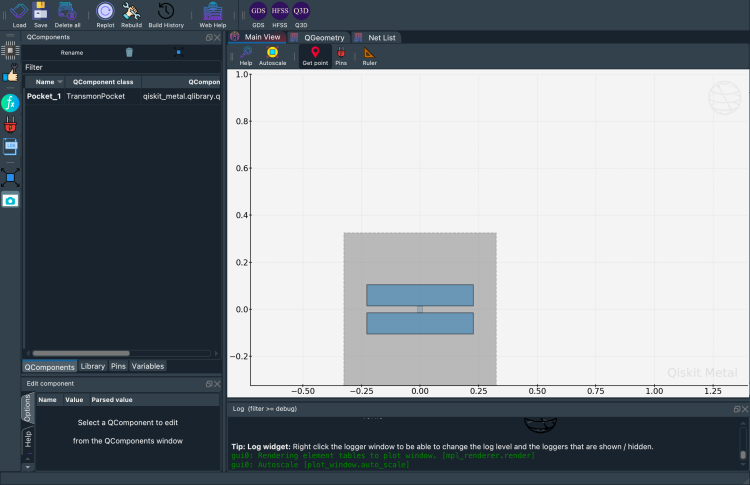

In [6]:
gui.autoscale()
gui.screenshot()

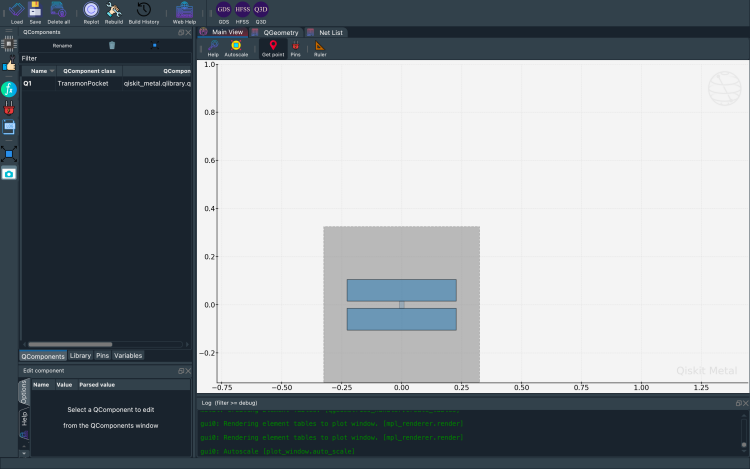

In [9]:
# making transmon pocket with name Q1 
design.delete_all_components() 
gui.rebuild() 

q1 = TransmonPocket(design, 'Q1')
gui.rebuild() 
gui.autoscale()
gui.screenshot() 

This QComponent is not function yet. It is just two rectangular pads with a thin strip of metal connecting them. For a QComponent to be functional, it needs QPins defining where the transmon pocket connects to CPWs. This will be discussed shortly. 

In [10]:
q1

name:    Q1
class:   TransmonPocket        
options: 
  'pos_x'             : '0.0um',                      
  'pos_y'             : '0.0um',                      
  'orientation'       : '0.0',                        
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'connection_pads'   : {
                        },
  'pad_gap'           : '30um',                       
  'inductor_width'    : '20um',                       
  'pad_width'         : '455um',                      
  'pad_height'        : '90um',                       
  'pocket_width'      : '650um',                      
  'pocket_height'     : '650um',                      
  'hfss_wire_bonds'   : False,                        
  'q3d_wire_bonds'    : False,                        
  'aedt_q3d_wire_bonds': False,                        
  'aedt_hfss_wire_bonds': False,                        
  'hfss_inductance'   : '10nH',                       
  'hfss_ca

In [15]:
q1.options.pos_x = '2.0 mm' 
q1.options.pos_y = '2.0 mm' 
q1.options.pad_height = '250 um' 
q1.options.pad_width = '300 um'

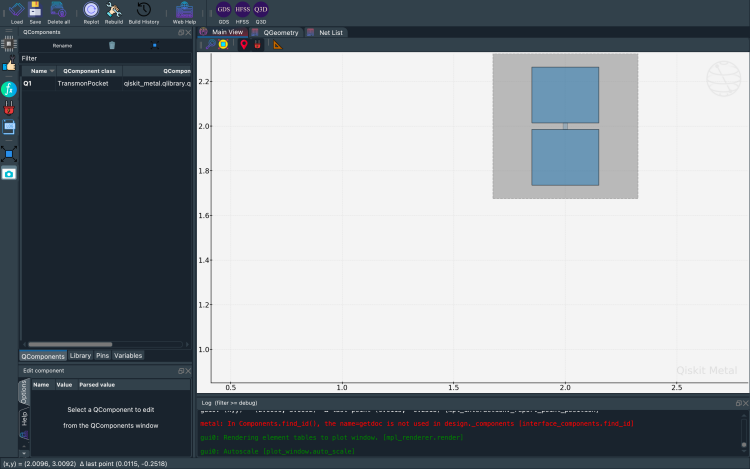

In [16]:
gui.rebuild()
gui.autoscale() 
gui.screenshot() 

In [14]:
%metal_print Copying a QComponent

In [36]:
design.overwrite_enabled=True
q1_copy = design.copy_qcomponent(q1, 'Q3_copy')


In [38]:
q1_copy.options.pos_x = '-2.0 mm' 
gui.rebuild() 
gui.autoscale() 

In [40]:
newcopies = design.copy_multiple_qcomponents(
    [q1, q1_copy], 
    ['Q3', 'Q4'], 
    [
        dict(pos_y='-2.0mm'), 
        dict(pos_y='-2.0mm'), 
    ]
)

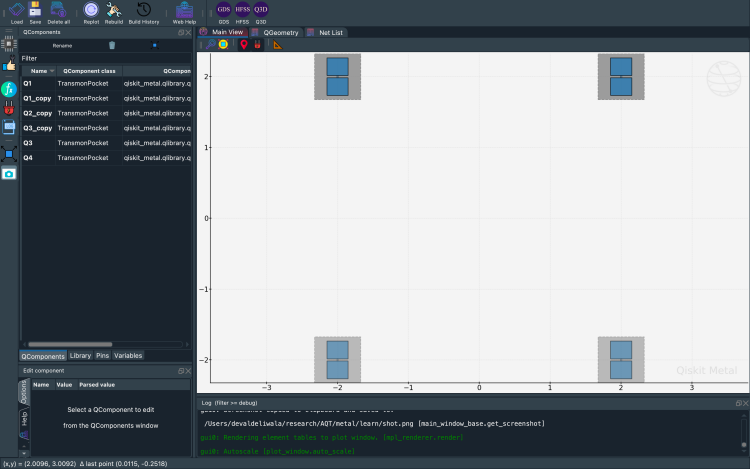

In [44]:
gui.rebuild()
gui.autoscale()
gui.screenshot()